In [ ]:
import os
import cv2
import torch
import time
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms import functional as F
from torchvision.models.detection import ssdlite320_mobilenet_v3_large # Modelo
from torchvision.models.detection import SSDLite320_MobileNet_V3_Large_Weights # Pesos

In [2]:
# Carregar modelo SSD Lite
weights = SSDLite320_MobileNet_V3_Large_Weights.DEFAULT
model = ssdlite320_mobilenet_v3_large(weights=weights)

model.eval()

classes = weights.meta["categories"]

Downloading: "https://download.pytorch.org/models/ssdlite320_mobilenet_v3_large_coco-a79551df.pth" to /home/orlandojunior/.cache/torch/hub/checkpoints/ssdlite320_mobilenet_v3_large_coco-a79551df.pth


100%|██████████| 13.4M/13.4M [00:01<00:00, 12.8MB/s]


In [3]:
# Lista das imagens
extensoes_validas = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

In [4]:
arquivos_imagem = [
    arquivo for arquivo in os.listdir("./data/") if arquivo.lower().endswith(extensoes_validas)
]


Processando: ./data/Laranja.jpg
Tempo: 39.79 ms

Processando: ./data/Peixes.jpg
Tempo: 38.12 ms

Processando: ./data/Familia.jpg
Tempo: 34.48 ms

Processando: ./data/Rua.jpg
Tempo: 37.01 ms

Processando: ./data/Horse.jpg
Tempo: 24.55 ms

Processando: ./data/Bus.jpg
Tempo: 32.83 ms

Processando: ./data/Ladrao3.jpg
Tempo: 33.66 ms

Processando: ./data/Ladrao2.jpg
Tempo: 38.08 ms

Processando: ./data/Colorido_Cinza.jpg
Tempo: 29.24 ms

Processando: ./data/Ladrao4.jpg
Tempo: 37.71 ms

Processando: ./data/Shopping.jpg
Tempo: 37.93 ms

Processando: ./data/Ladrao.jpg
Tempo: 41.67 ms


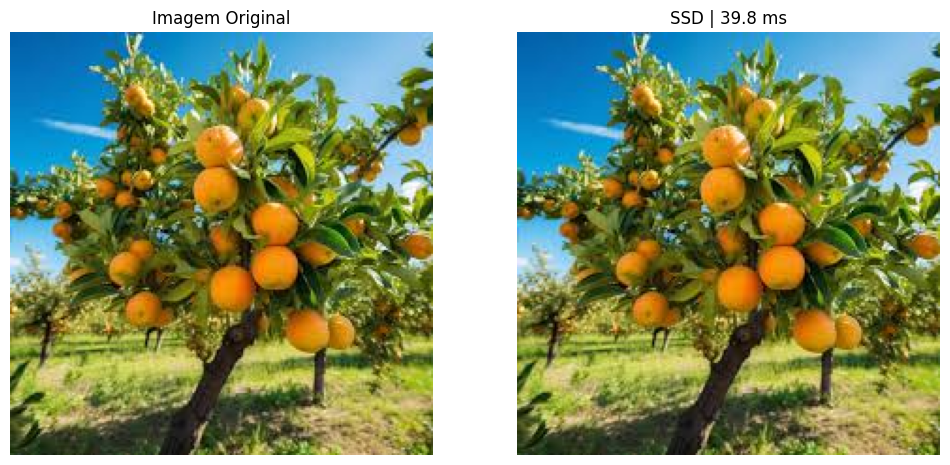

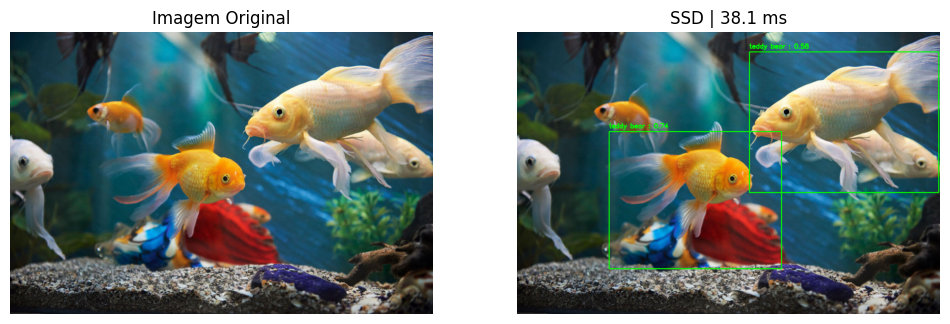

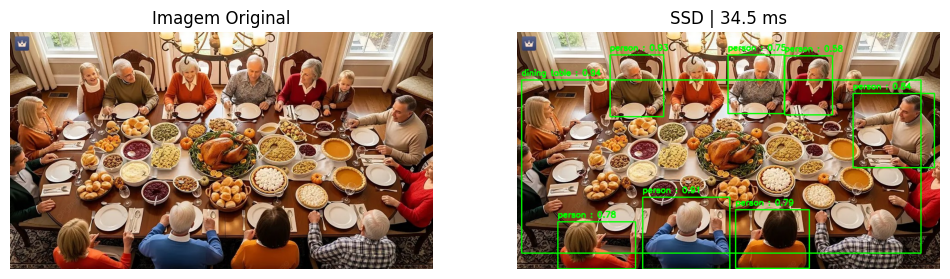

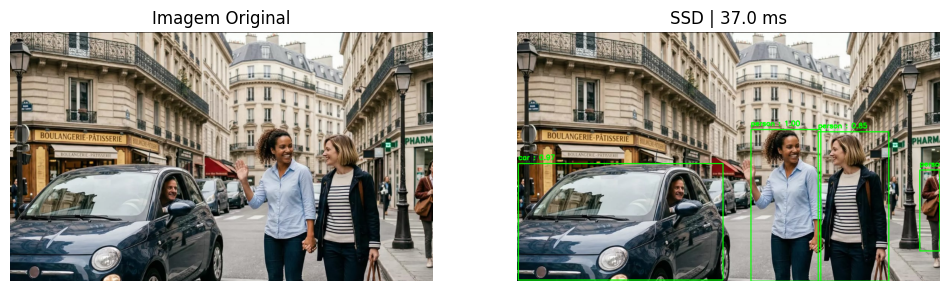

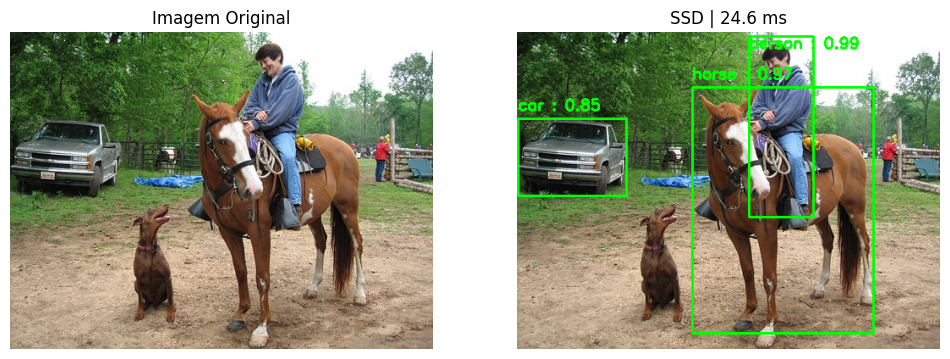

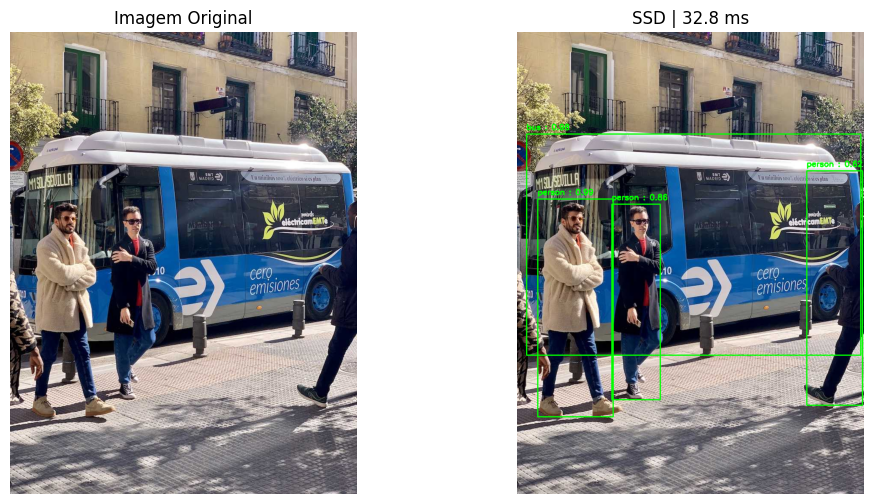

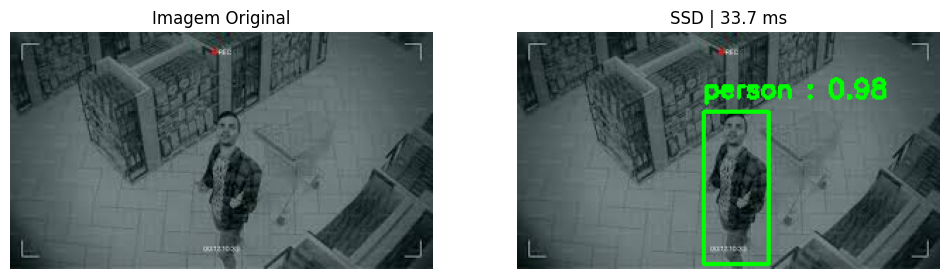

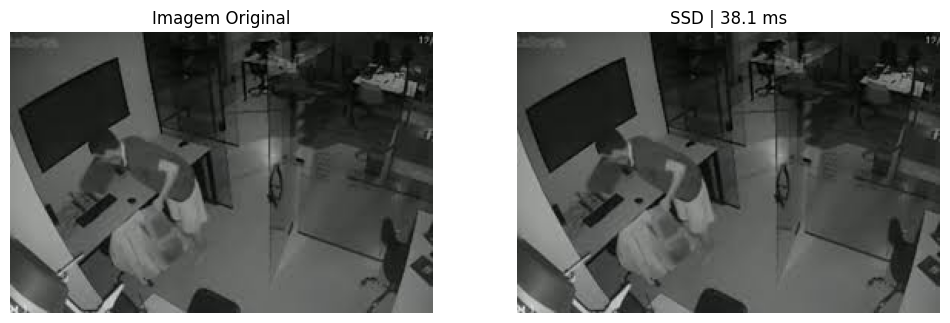

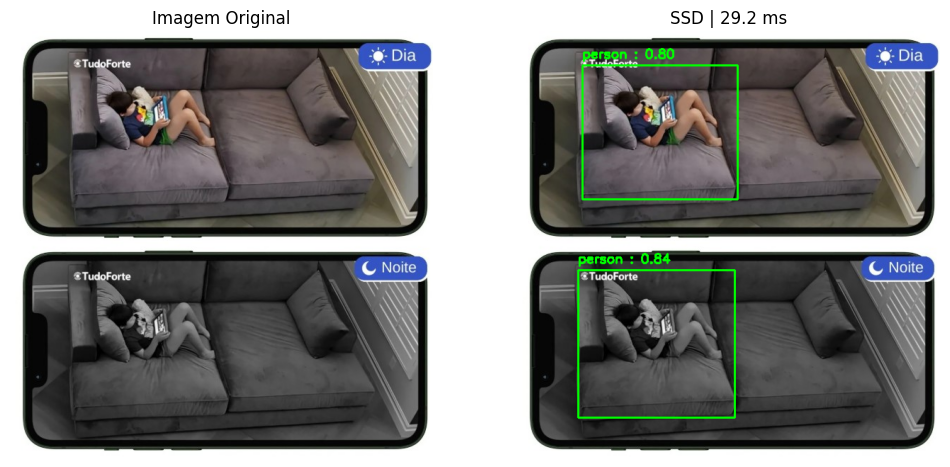

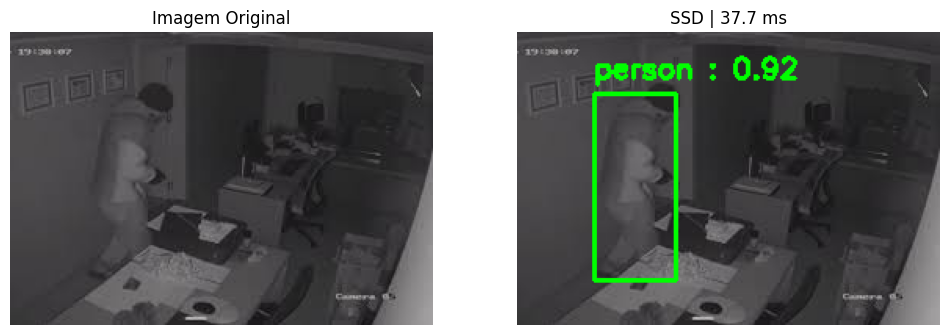

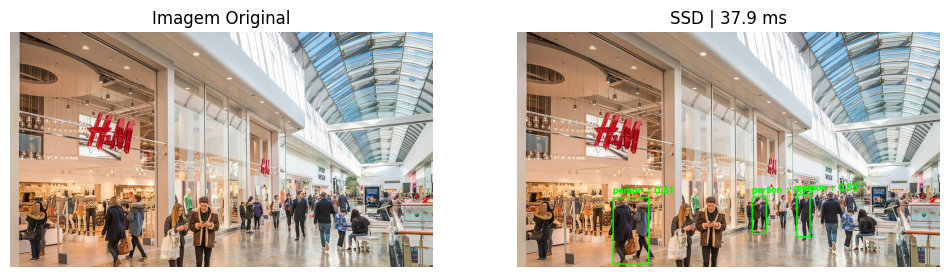

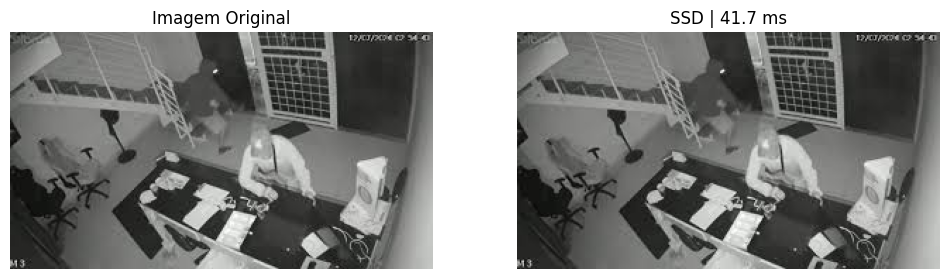

In [9]:
# Aplicar o modelo ssd em cada imagem

DIR = "./data/"
for img in arquivos_imagem:
    caminho = os.path.join(DIR,img)
    print(f'\nProcessando: {caminho}')
    
    img_pil = Image.open(caminho).convert("RGB")
    img_tensor = F.to_tensor(img_pil) #normalizada com valores 0 e 1
    
    inicio = time.time()
    
    with torch.no_grad():
        results = model([img_tensor])
    fim = time.time()
    
    tempo_ms = (fim - inicio) * 1000
    
    print(f"Tempo: {tempo_ms:.2f} ms")
    resultado = results[0]
    img_original = cv2.imread(caminho)
    img_detectada = cv2.imread(caminho)
    
    # Detecções
    
    for box, score, label in zip(
        resultado["boxes"],
        resultado["scores"],
        resultado["labels"]
    ):
        if score >= 0.50:
            x1,y1,x2,y2 = box.int().tolist()
            nome_classe = classes[label]
            texto = f"{nome_classe} : {score:.2f}"
            
            cv2.rectangle(
                img_detectada,
                (x1,y1),
                (x2,y2),
                (0,255,0),
                2
            )
            
            cv2.putText(
                img_detectada,
                texto,
                (x1,max(y1- 10,20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0,255,0),
                2
            )
            
    img_original_rgb = cv2.cvtColor(img_original,cv2.COLOR_BGR2RGB)
    imagem_anotada_rgb = cv2.cvtColor(img_detectada,cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    plt.imshow(img_original_rgb)
    plt.title("Imagem Original")
    plt.axis("off")
    
    plt.subplot(1,2,2)
    plt.imshow(imagem_anotada_rgb)
    plt.title(f"SSD | {tempo_ms:.1f} ms")
    plt.axis("off")

In [ ]:
()